# Telco Customer Churn — Exploratory Data Analysis

**Goal:** Understand the dataset before building a churn prediction model.

- Dataset: 7,043 customers · 21 columns
- Target: `Churn` (Yes / No)

**Questions we want to answer:**
1. How is the target distributed? (class imbalance?)
2. Which features separate churners from loyal customers?
3. Are there data quality issues (missing values, wrong dtypes) to fix?

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
# Load the data (works whether jupyter is launched from the repo root or the notebooks/ folder)
from pathlib import Path

p1 = Path("../data/Telco-Customer-Churn.csv")
p2 = Path("data/Telco-Customer-Churn.csv")
DATA_PATH = p1 if p1.exists() else p2

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Data overview

In [3]:
# Column types + missing values per column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Summary statistics for numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 2. Clean `TotalCharges`

`TotalCharges` is read as **object (text)** even though it is a number — a classic data-quality gotcha. Let's inspect why:

In [5]:
print("dtype:", df["TotalCharges"].dtype)

# Rows that look empty (whitespace only)
bad = df["TotalCharges"].str.strip() == ""
print("Rows with empty TotalCharges:", bad.sum())

# Convert to numeric; errors='coerce' turns invalid entries into NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("NaN after conversion:", df["TotalCharges"].isna().sum())

dtype: object
Rows with empty TotalCharges: 11
NaN after conversion: 11


## 3. Target distribution

Churn is **imbalanced**: ~73.5% No vs ~26.5% Yes.

➡️ Consequence: **accuracy is misleading** (a model that always predicts "No" gets 73.5% accuracy but is useless). We will evaluate with **AUC, Recall, F1** instead.

Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


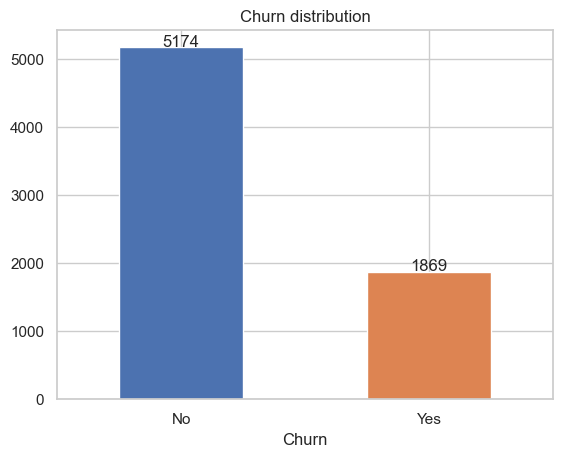

In [6]:
# Target distribution (counts + proportions)
print(df["Churn"].value_counts(normalize=True).round(3))

ax = df["Churn"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
ax.set_title("Churn distribution")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(df["Churn"].value_counts()):
    ax.text(i, v + 20, str(v), ha="center")
plt.show()

## 4. Numerical features vs Churn

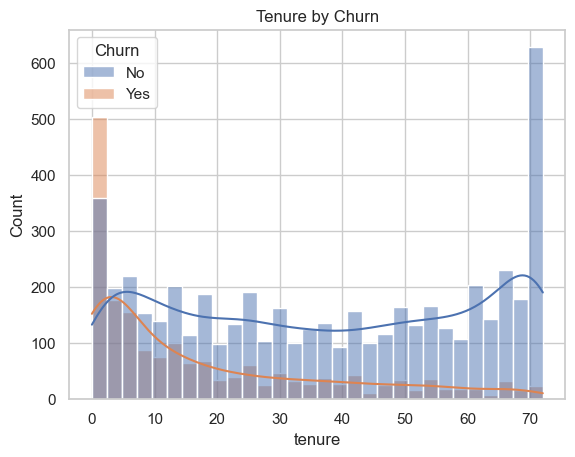

In [7]:
# tenure: how long (months) the customer has been with the company
sns.histplot(data=df, x="tenure", hue="Churn", kde=True, bins=30)
plt.title("Tenure by Churn")
plt.show()

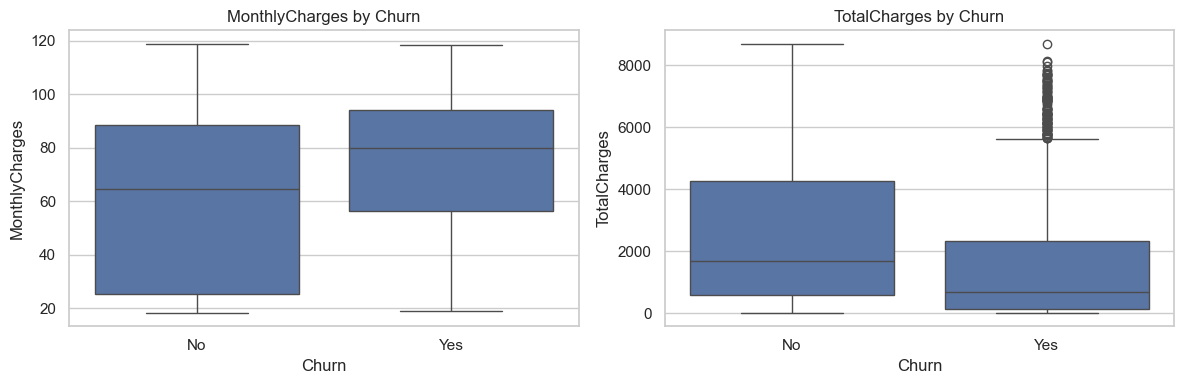

In [8]:
# MonthlyCharges vs TotalCharges by Churn
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[0])
sns.boxplot(data=df, x="Churn", y="TotalCharges", ax=axes[1])
axes[0].set_title("MonthlyCharges by Churn")
axes[1].set_title("TotalCharges by Churn")
plt.tight_layout()
plt.show()

## 5. Categorical features vs Churn

Churn rate (%) per category — the higher the bar, the more that group churns.

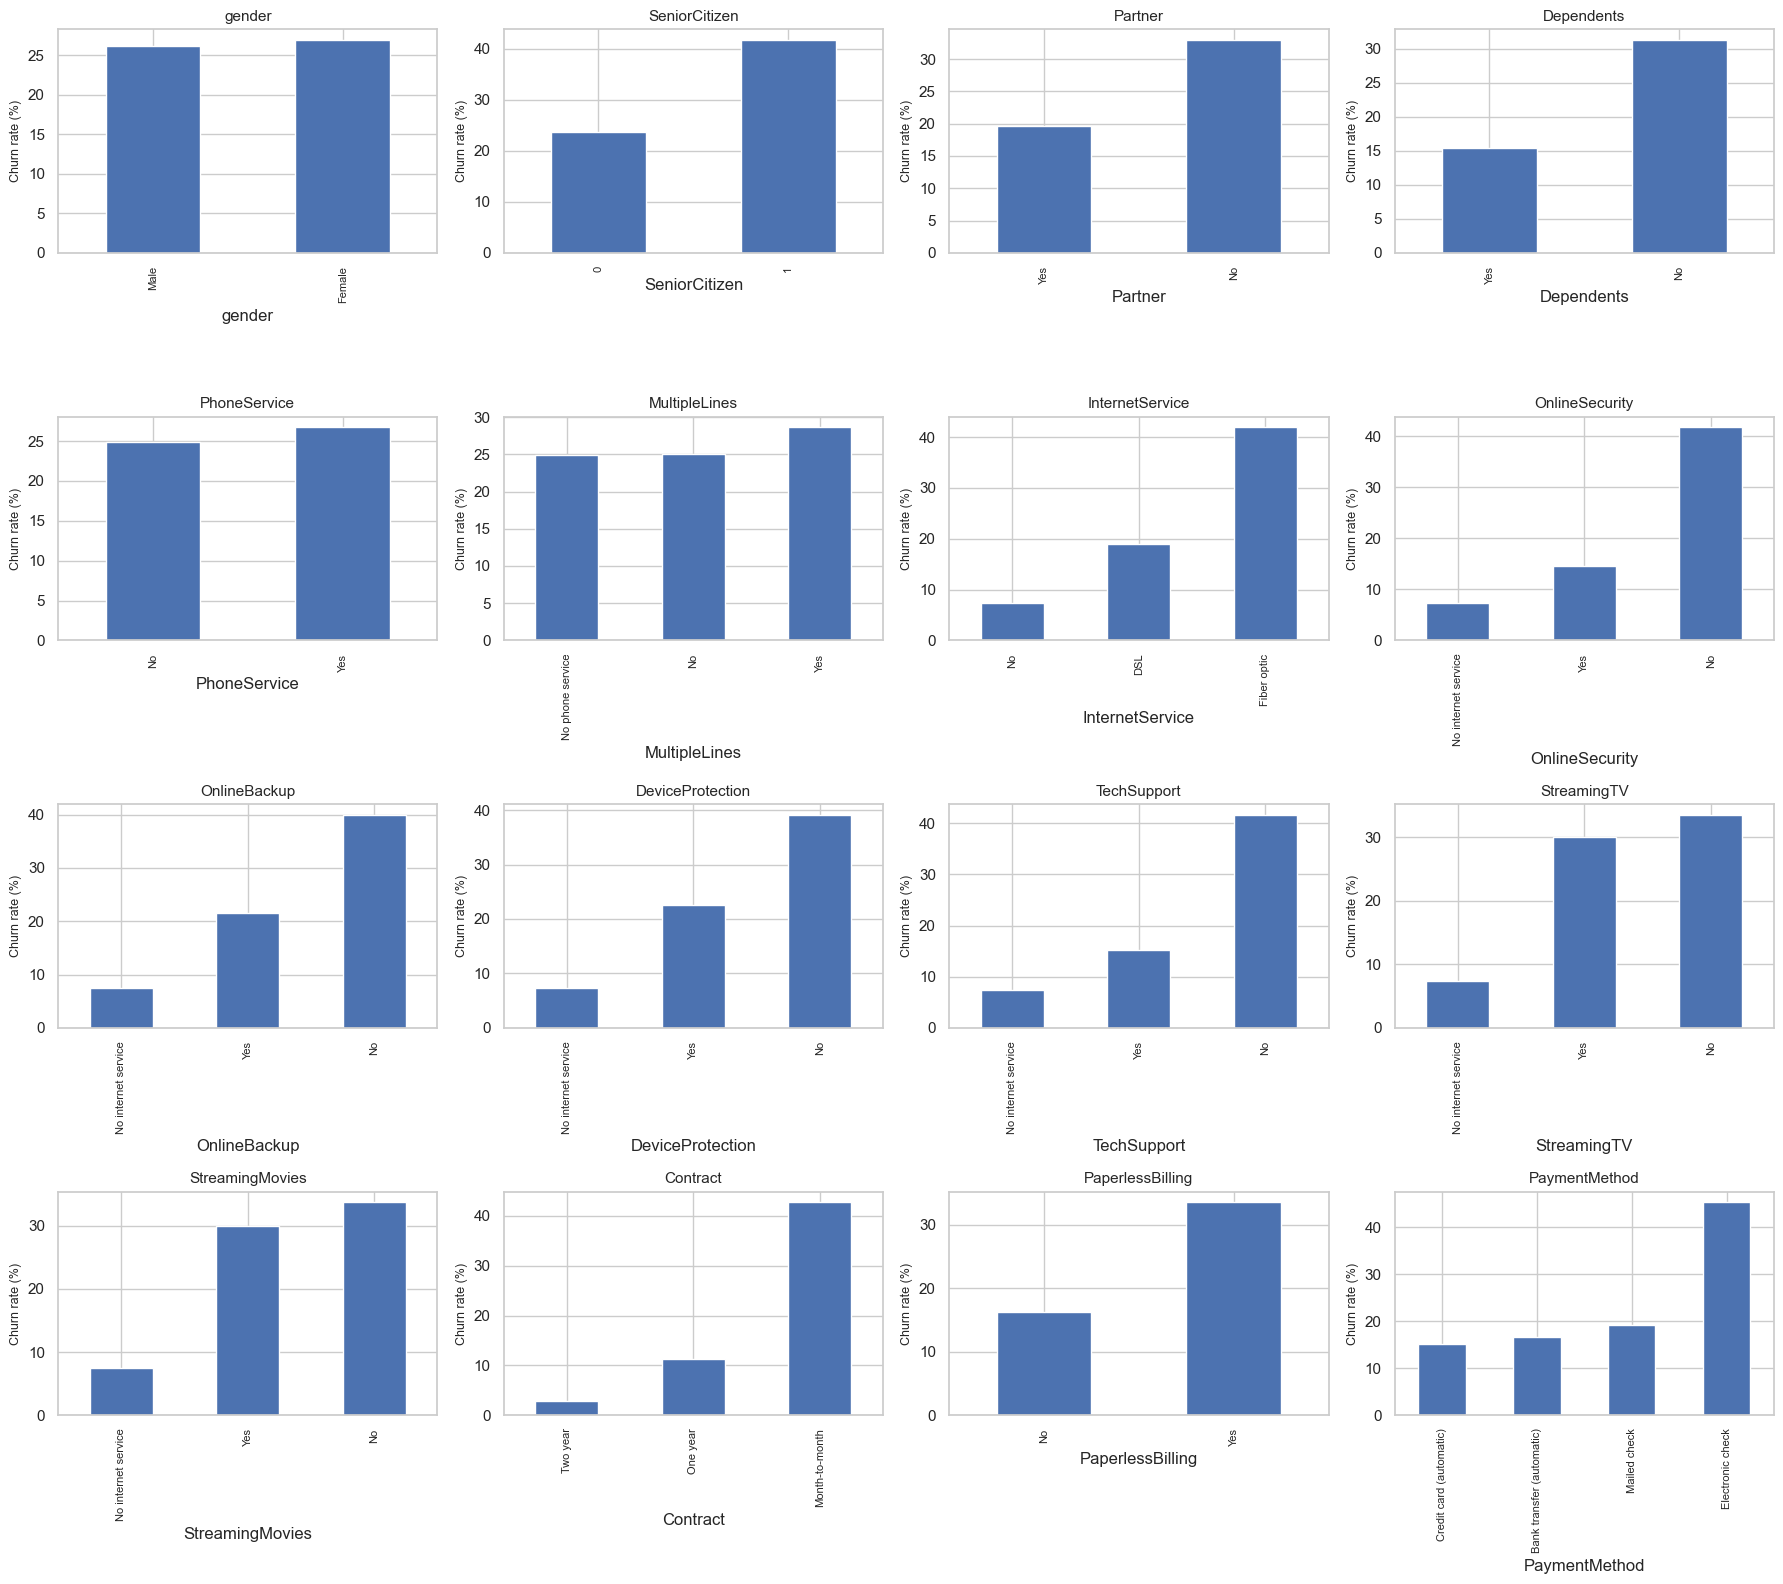

In [9]:
cat_cols = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService",
            "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
            "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
            "Contract", "PaperlessBilling", "PaymentMethod"]

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
for ax, col in zip(axes.flat, cat_cols):
    rate = df.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean() * 100).sort_values()
    rate.plot(kind="bar", ax=ax, color="#4C72B0")
    ax.set_title(col, fontsize=11)
    ax.set_ylabel("Churn rate (%)", fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
plt.tight_layout()
plt.show()

## 6. Correlation

Numerical features only (we encode `Churn` as 0/1 for this check).

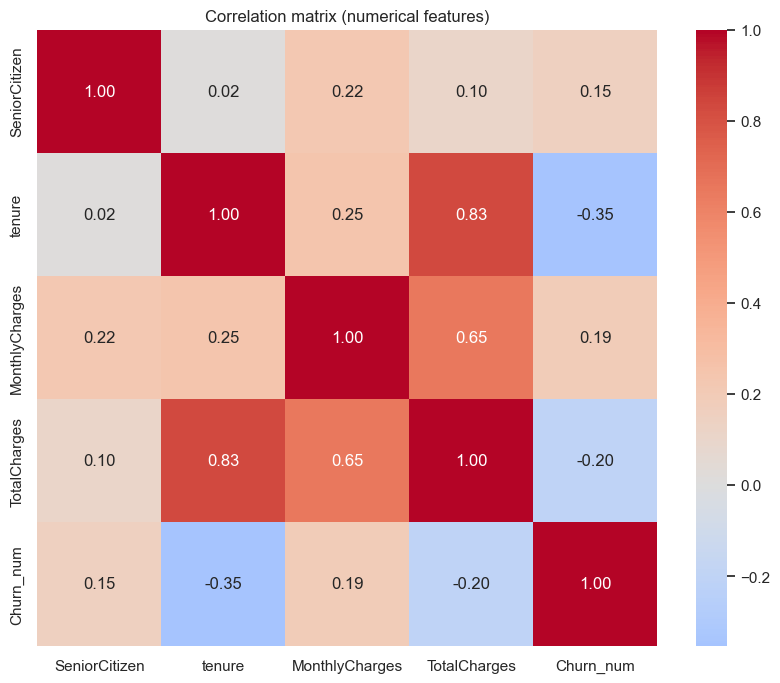

In [10]:
# Encode Churn for the correlation matrix
corr_df = df.copy()
corr_df["Churn_num"] = (corr_df["Churn"] == "Yes").astype(int)
numeric = corr_df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 8))
sns.heatmap(numeric.corr(), annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Correlation matrix (numerical features)")
plt.show()

## 7. Key insights

- **`tenure` is the strongest signal**: new customers churn much more than long-standing ones.
- **Higher `MonthlyCharges` → higher churn**: customers who pay more are more likely to leave.
- **`Contract` matters a lot**: month-to-month customers churn far more than 1-2 year contracts.
- **Support & security services reduce churn**: `TechSupport`, `OnlineSecurity`, `OnlineBackup` = Yes → lower churn rate.
- **Data quality fix**: `TotalCharges` contained ~11 whitespace-only values → fixed with `pd.to_numeric(errors='coerce')`.
- **Class imbalance** (~26.5% churn) → evaluate with **AUC / Recall / F1**, not accuracy.

## 8. Next steps

1. Encode categorical features
2. Handle missing values (NaN in `TotalCharges`)
3. Train a baseline (Dummy / LogisticRegression), then XGBoost
4. Track experiments with MLflow